INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6


c:\ProgramData\anaconda3\envs\dl_gpu_env\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


261/261 [==============================] - 23s 72ms/step


C:\Users\r\AppData\Local\Temp\ipykernel_27580\1928591591.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label_encoder.inverse_transform(y_train), order=np.unique(label_encoder.inverse_transform(y_train)), palette='tab20')


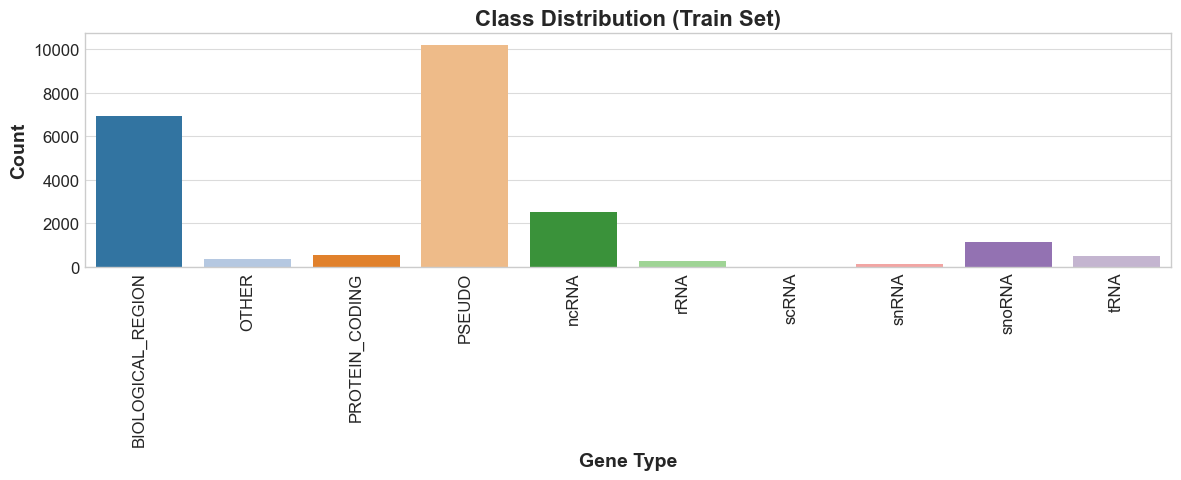

C:\Users\r\AppData\Local\Temp\ipykernel_27580\1928591591.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rare_classes.index, y=rare_classes.values, palette='Reds_r')


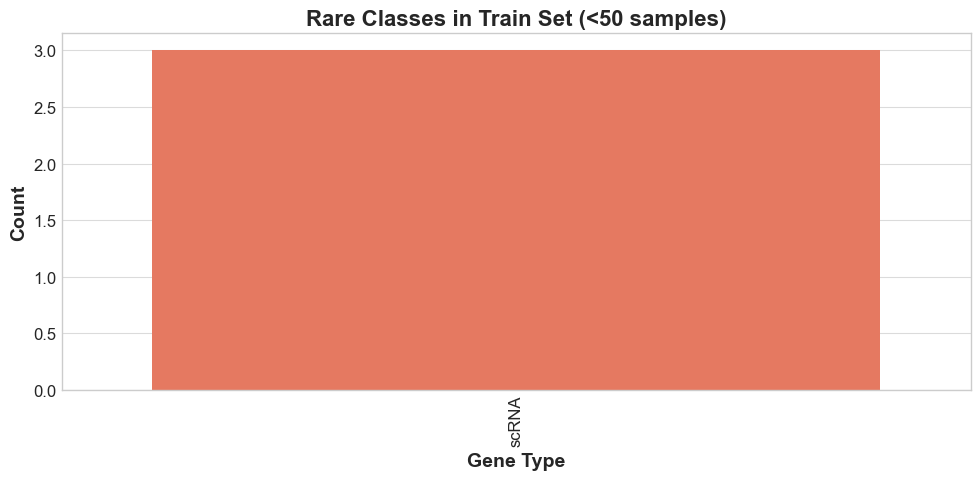

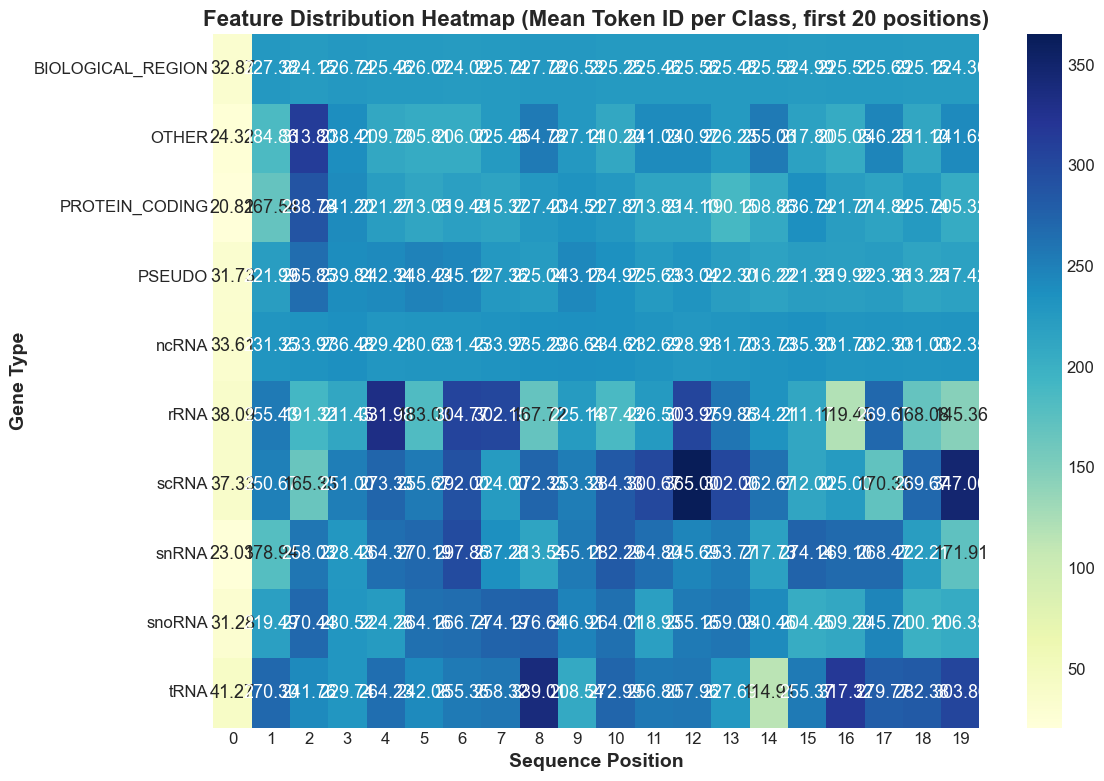

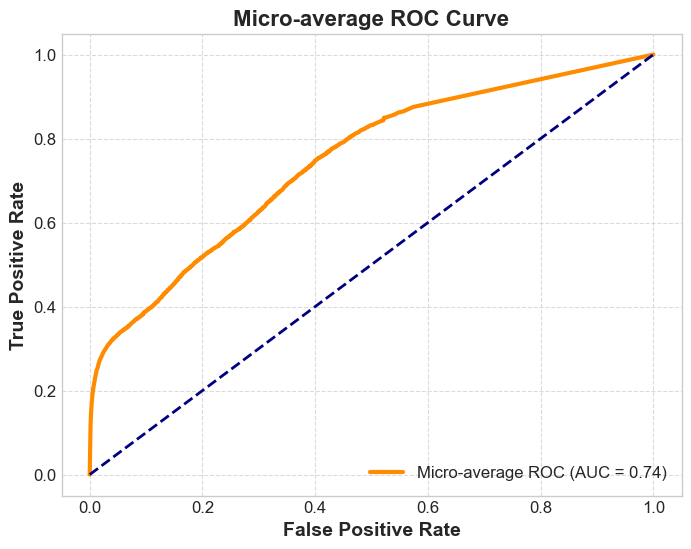

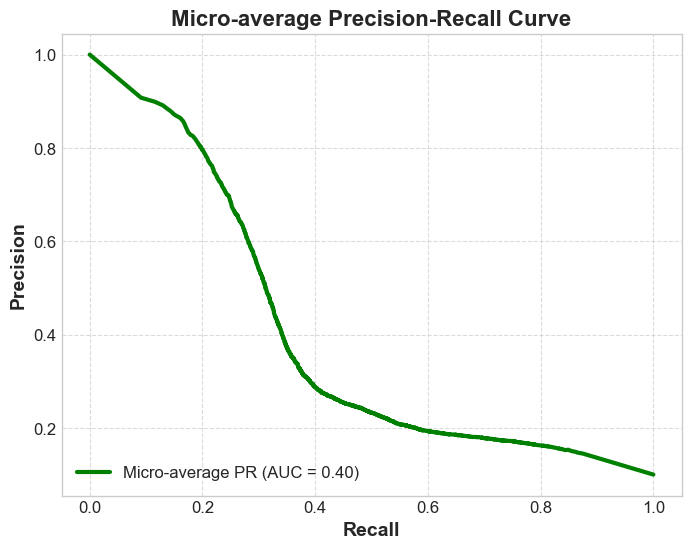

In [1]:
# 📌 Part 0: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
import os

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,
})

# 📌 Part 1: Load Data
train_df = pd.read_csv("DATA/train.csv").drop(columns=['Unnamed: 0'], errors='ignore')
val_df = pd.read_csv("DATA/validation.csv").drop(columns=['Unnamed: 0'], errors='ignore')
test_df = pd.read_csv("DATA/test.csv").drop(columns=['Unnamed: 0'], errors='ignore')

# 📌 Part 2: Load Saved Artifacts
model = load_model("dna_classifier_model.h5")

with open("dna_label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

with open("dna_vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("training_history.pkl", "rb") as f:
    history = pickle.load(f)

num_classes = len(label_encoder.classes_)

# 📌 Part 3: k-mer Tokenization and Encoding
def kmer_tokenizer(seq, k=4):
    return [seq[i:i+k] for i in range(len(seq)-k+1)]

def encode_and_pad(sequences, vocab, k=4, max_len=None):
    encoded = [[vocab.get(kmer, 0) for kmer in kmer_tokenizer(seq, k)] for seq in sequences]
    if max_len is None:
        max_len = max(len(seq) for seq in encoded)
    padded = pad_sequences(encoded, maxlen=max_len, padding='post', truncating='post')
    return padded

max_len = model.input_shape[1]

X_train_pad = encode_and_pad(train_df['NucleotideSequence'], vocab, max_len=max_len)
X_val_pad = encode_and_pad(val_df['NucleotideSequence'], vocab, max_len=max_len)
X_test_pad = encode_and_pad(test_df['NucleotideSequence'], vocab, max_len=max_len)

y_train = label_encoder.transform(train_df['GeneType'])
y_val = label_encoder.transform(val_df['GeneType'])
y_test = label_encoder.transform(test_df['GeneType'])

# Binarized labels for ROC/PR
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# 📌 Part 4: Predictions
y_pred_proba = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📌 Part 5: Class Distribution Bar Plot
plt.figure(figsize=(12,5))
sns.countplot(x=label_encoder.inverse_transform(y_train), order=np.unique(label_encoder.inverse_transform(y_train)), palette='tab20')
plt.title('Class Distribution (Train Set)', fontsize=16)
plt.xticks(rotation=90)
plt.xlabel('Gene Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Rare Class Analysis
rare_classes = train_df['GeneType'].value_counts()[train_df['GeneType'].value_counts() < 50]
plt.figure(figsize=(10,5))
sns.barplot(x=rare_classes.index, y=rare_classes.values, palette='Reds_r')
plt.title('Rare Classes in Train Set (<50 samples)')
plt.xticks(rotation=90)
plt.xlabel('Gene Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



# 📌 Part 7: ROC & PR Curves (Micro-Average)
fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
pr_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], color='darkorange', lw=3, label='Micro-average ROC (AUC = %0.2f)' % roc_auc["micro"])
plt.plot([0,1],[0,1],color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Micro-average Precision-Recall Curve
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_pred_proba.ravel())
pr_auc["micro"] = auc(recall["micro"], precision["micro"])

plt.figure(figsize=(8,6))
plt.plot(recall["micro"], precision["micro"], color='green', lw=3, label='Micro-average PR (AUC = %0.2f)' % pr_auc["micro"])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-average Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


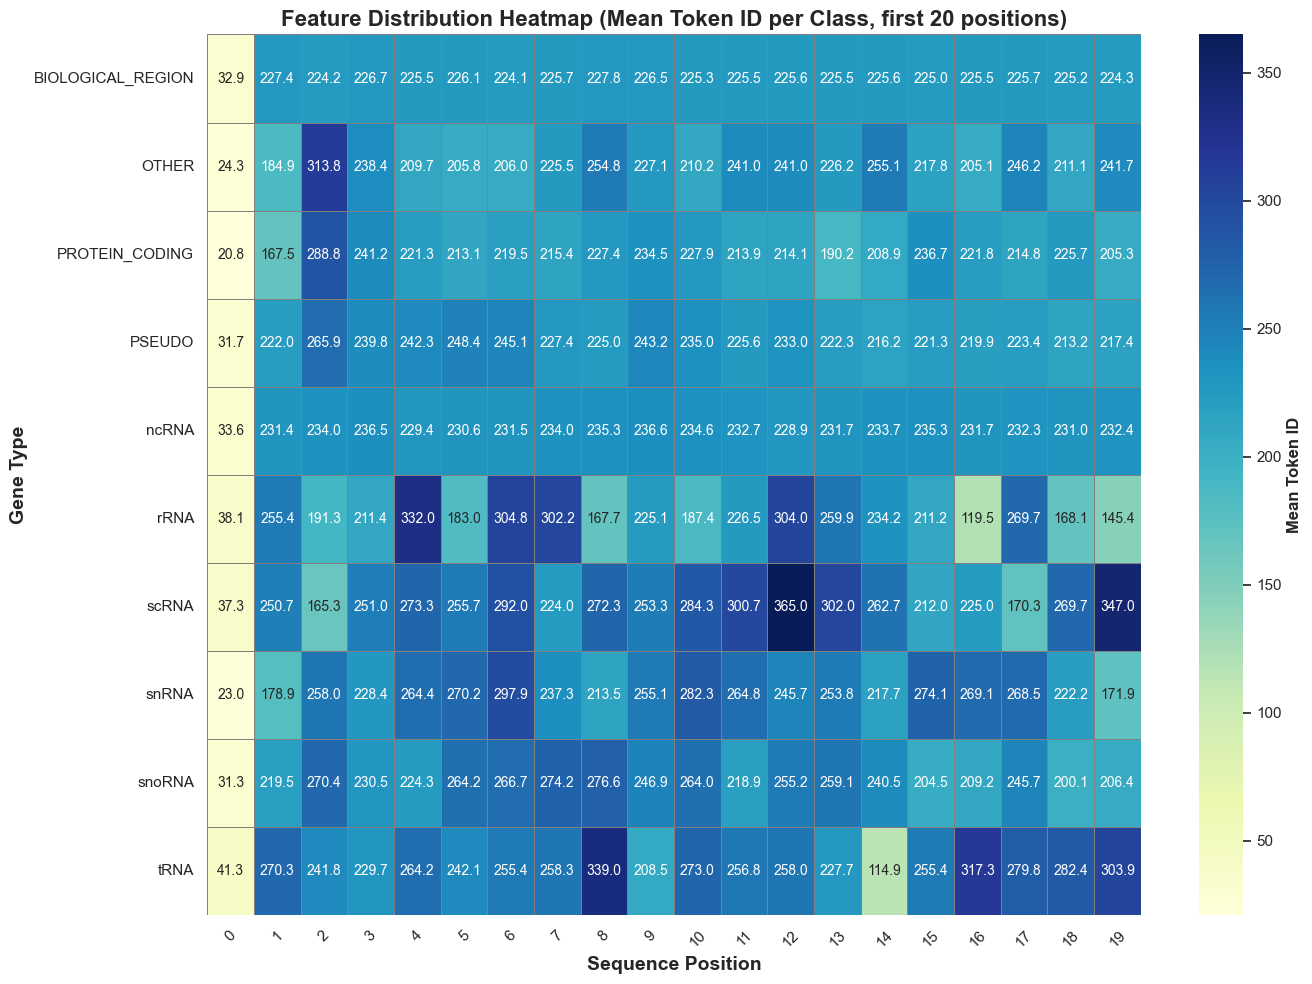

In [6]:
# 📌 Part 6: Feature Distribution Heatmap (first N positions)
N = 20
df_features = pd.DataFrame(X_train_pad[:, :N])
df_features['GeneType'] = label_encoder.inverse_transform(y_train)

# Compute mean token value per class per position
heatmap_data = df_features.groupby('GeneType').mean()

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',            # shorter numbers fit better
    annot_kws={"size": 10},  # smaller font for annotations
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean Token ID'}
)
plt.title(f'Feature Distribution Heatmap (Mean Token ID per Class, first {N} positions)', fontsize=16, fontweight='bold')
plt.xlabel('Sequence Position', fontsize=14, fontweight='bold')
plt.ylabel('Gene Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

261/261 [==============================] - 19s 72ms/step


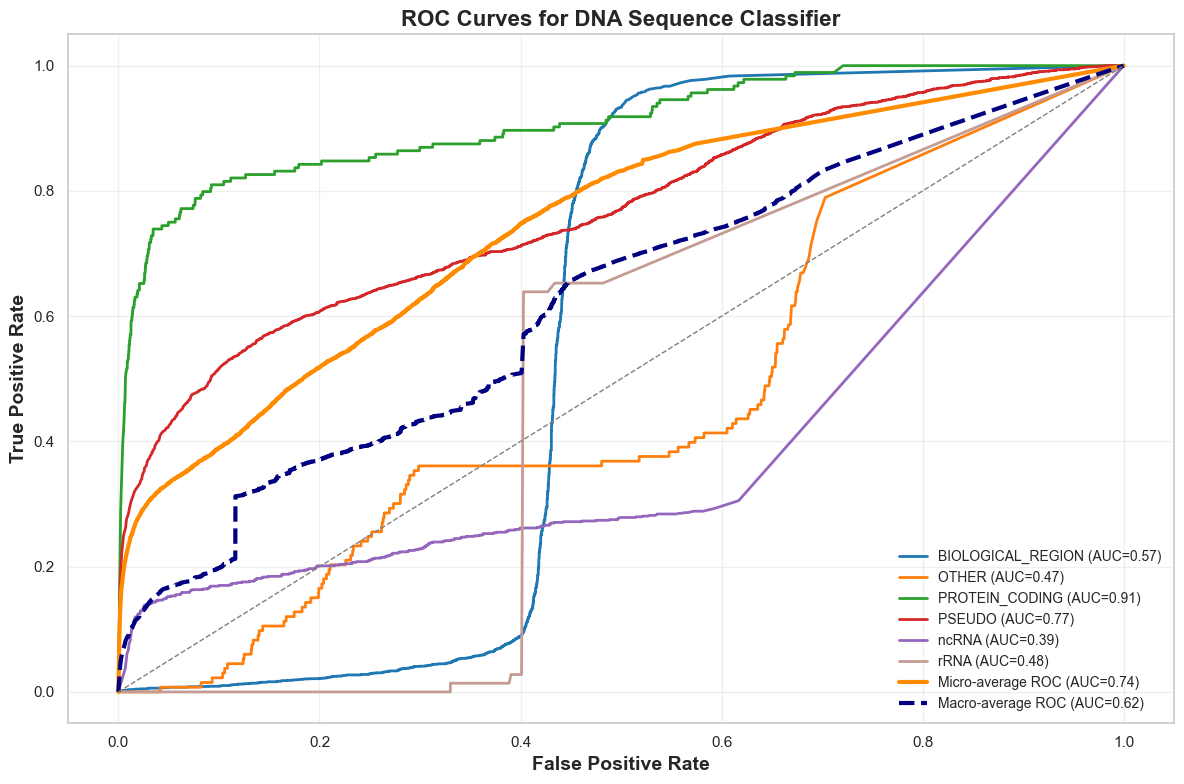

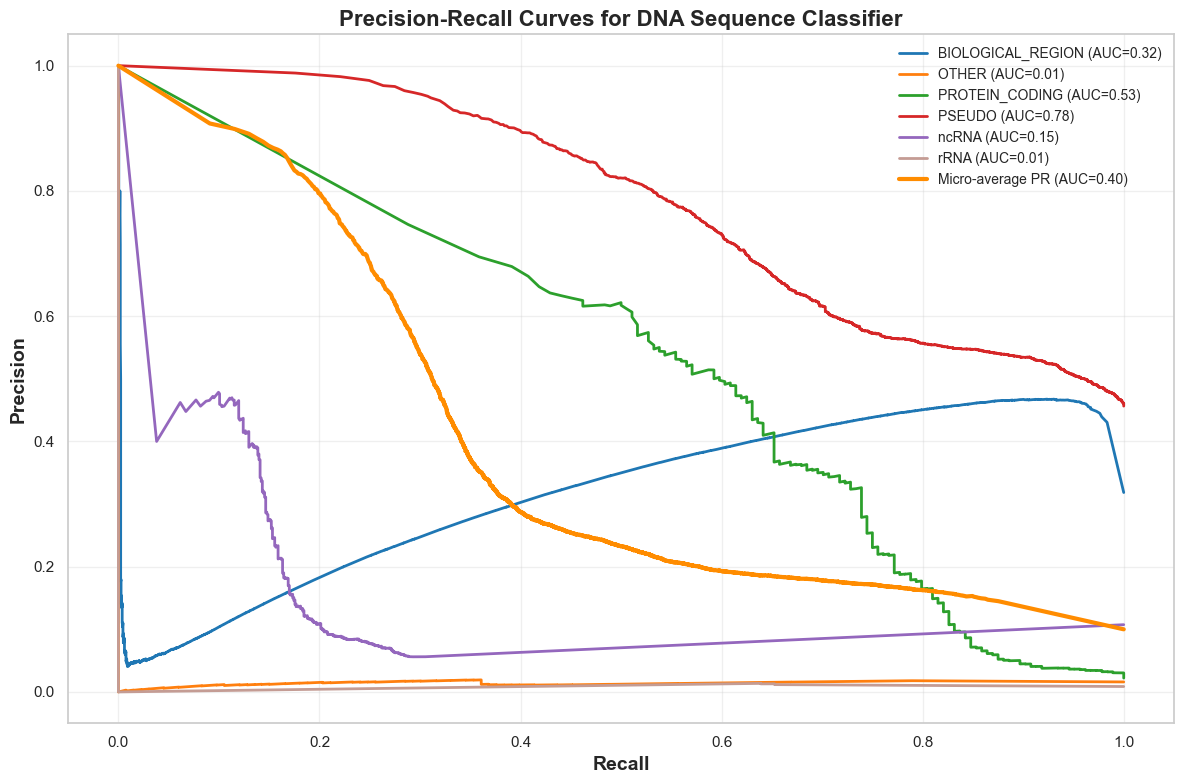

In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_pred_proba = model.predict(X_test_pad)

# Colors and line styles for clarity
colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
lw = 2

# -----------------------------
# ROC Curves: Per-Class + Macro/Micro
# -----------------------------
plt.figure(figsize=(12, 8))

# Compute per-class ROC
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    if i < 6:  # show only top 6 classes for clarity
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=lw, label=f'{label_encoder.classes_[i]} (AUC={roc_auc[i]:.2f})')

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
plt.plot(fpr["micro"], tpr["micro"], color='darkorange', lw=3, linestyle='-', label=f'Micro-average ROC (AUC={roc_auc["micro"]:.2f})')

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, color='navy', lw=3, linestyle='--', label=f'Macro-average ROC (AUC={roc_auc["macro"]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.title('ROC Curves for DNA Sequence Classifier', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Precision-Recall Curves
# -----------------------------
plt.figure(figsize=(12, 8))

precision = dict()
recall = dict()
pr_auc = dict()
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc[i] = auc(recall[i], precision[i])
    if i < 6:  # show only top 6 for clarity
        plt.plot(recall[i], precision[i], color=colors[i], lw=lw, label=f'{label_encoder.classes_[i]} (AUC={pr_auc[i]:.2f})')

# Micro-average PR
precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_pred_proba.ravel())
pr_auc["micro"] = auc(recall["micro"], precision["micro"])
plt.plot(recall["micro"], precision["micro"], color='darkorange', lw=3, linestyle='-', label=f'Micro-average PR (AUC={pr_auc["micro"]:.2f})')

plt.title('Precision-Recall Curves for DNA Sequence Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


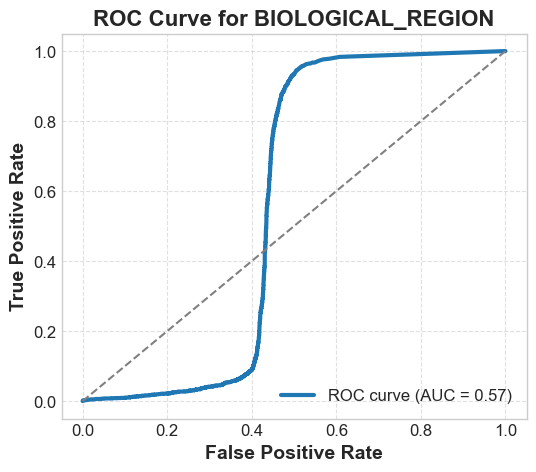

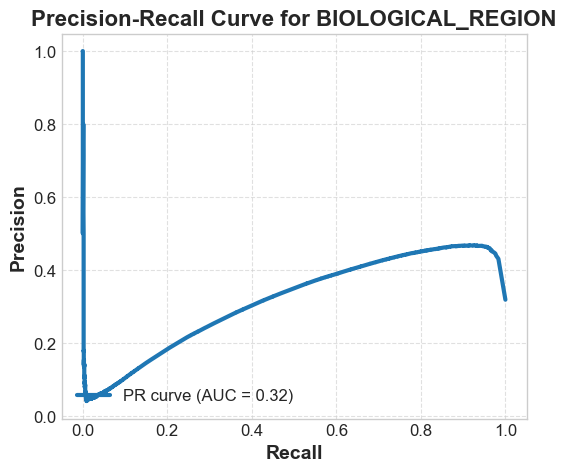

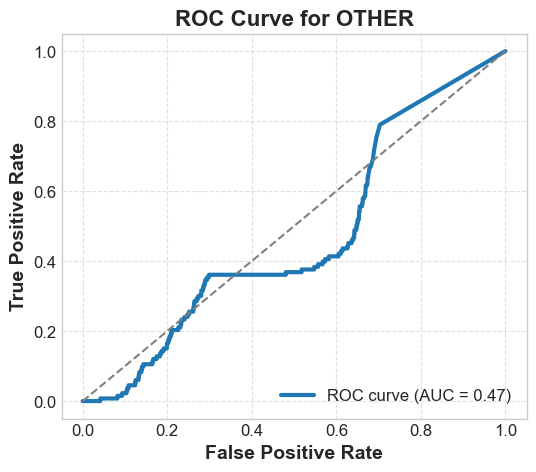

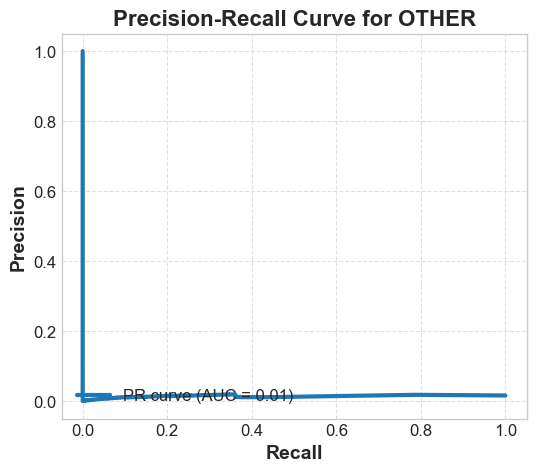

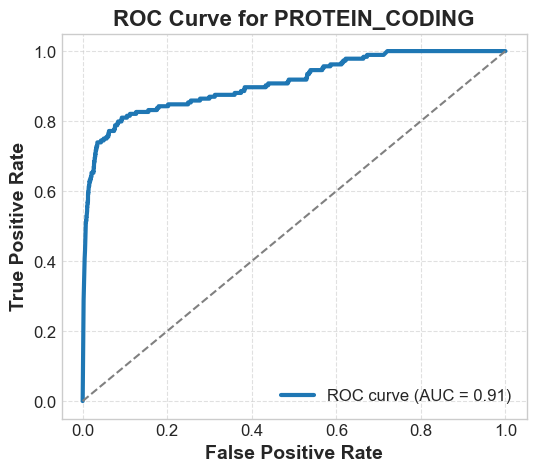

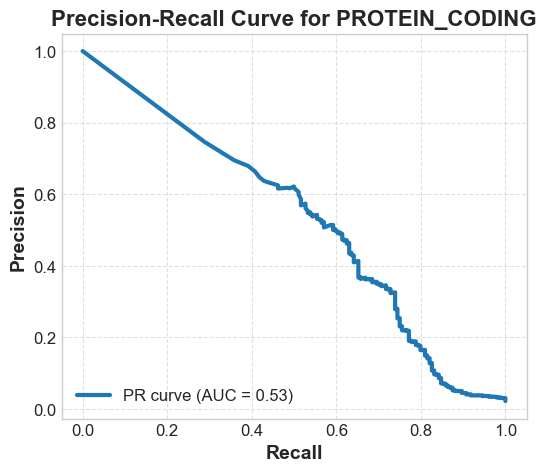

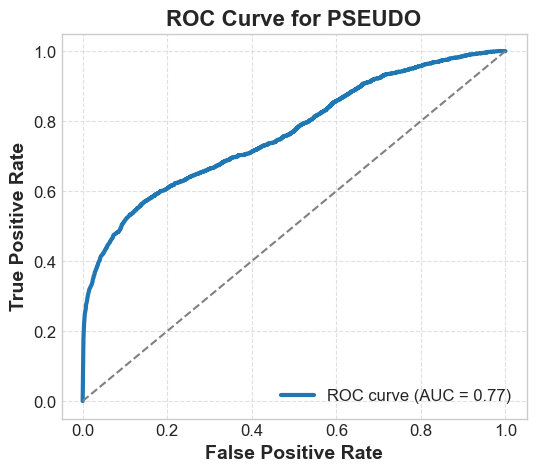

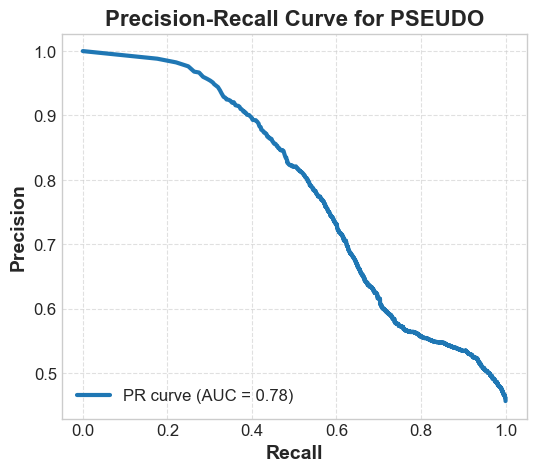

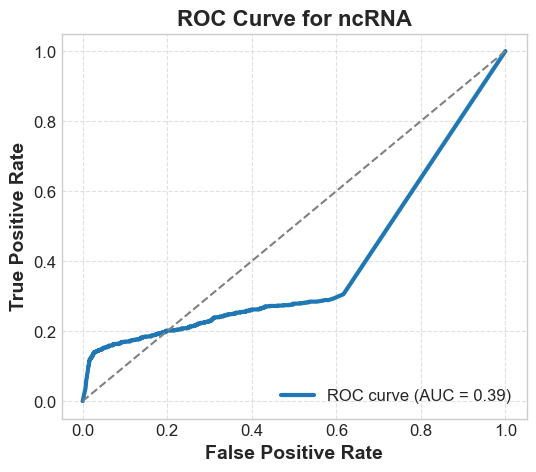

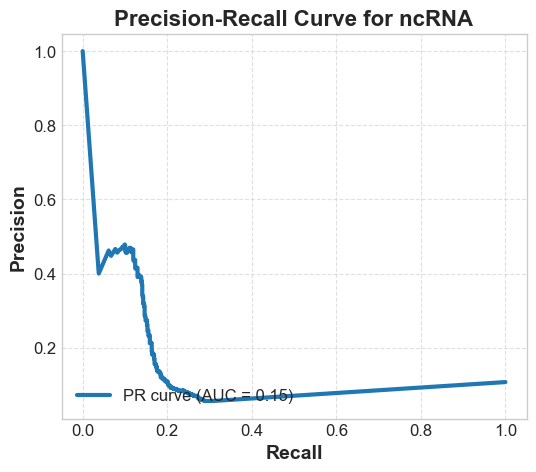

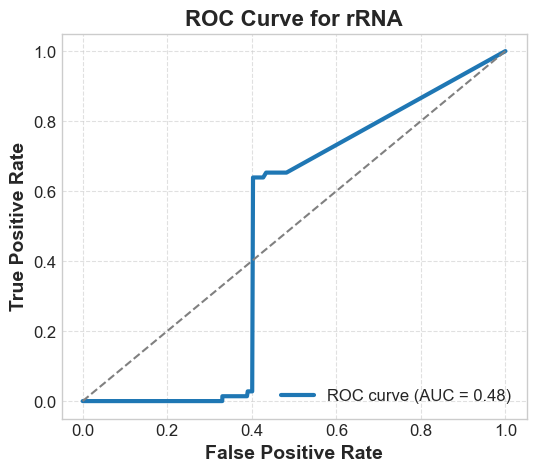

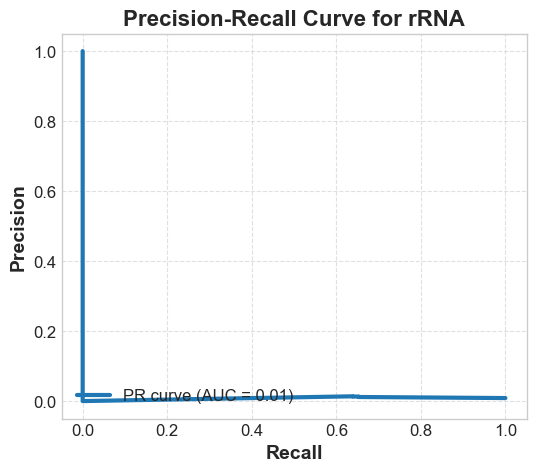

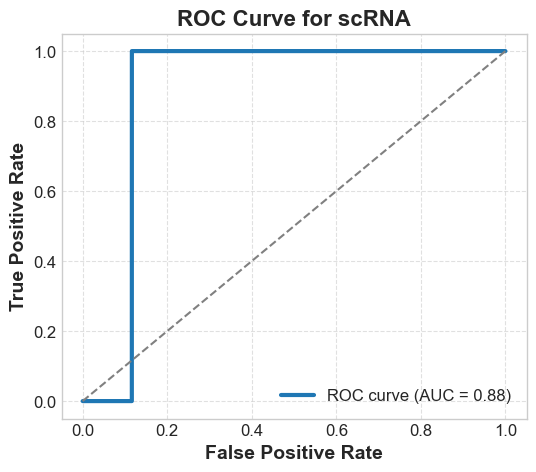

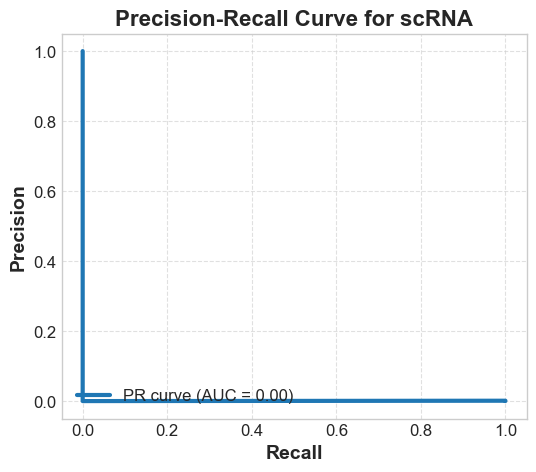

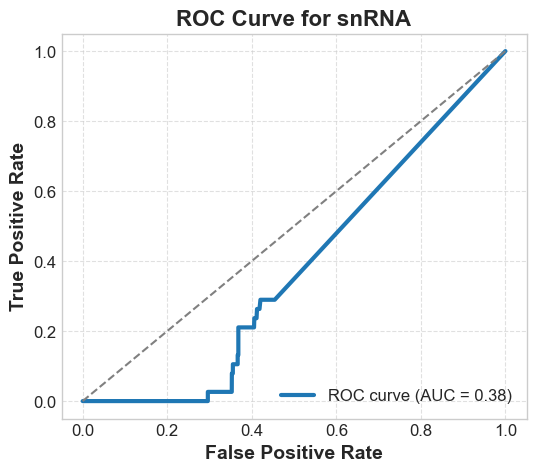

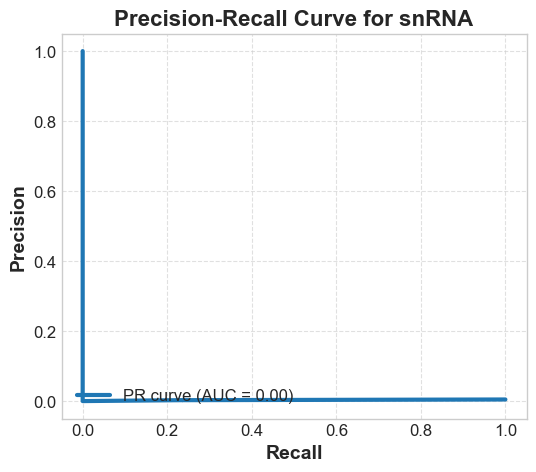

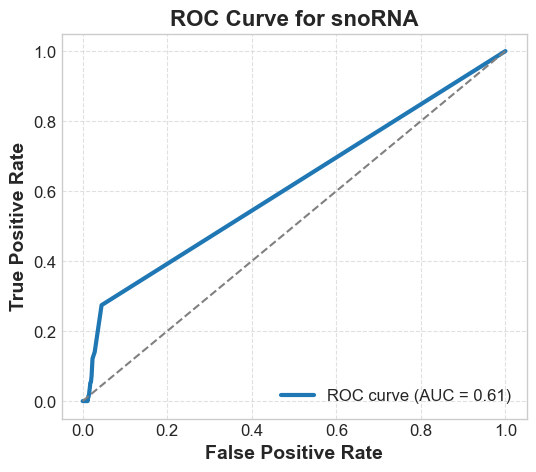

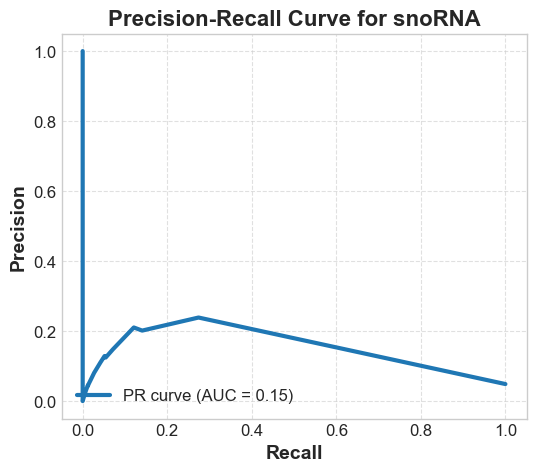

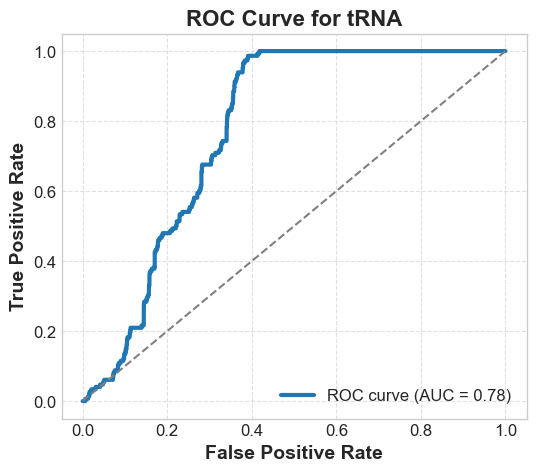

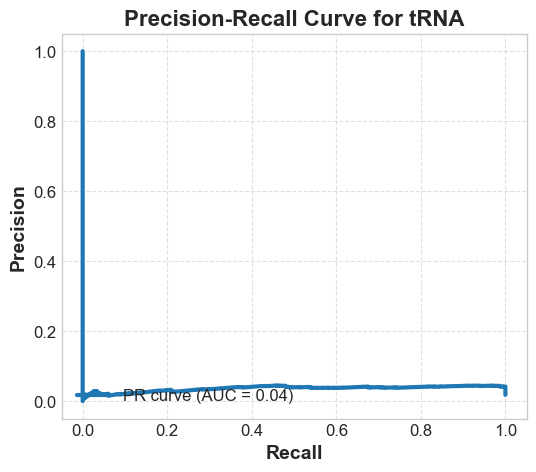

In [2]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# y_test_bin is already binarized (shape: num_samples x num_classes)
# y_pred_proba from model.predict (shape: num_samples x num_classes)

fpr = dict()
tpr = dict()
roc_auc = dict()
precision = dict()
recall = dict()
pr_auc = dict()

for i, class_name in enumerate(label_encoder.classes_):
    # ROC
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    # PR
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc[i] = auc(recall[i], precision[i])
    
    # Plot per-class ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr[i], tpr[i], lw=3, label=f'ROC curve (AUC = {roc_auc[i]:.2f})')
    plt.plot([0,1],[0,1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {class_name}')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    # Plot per-class PR
    plt.figure(figsize=(6,5))
    plt.plot(recall[i], precision[i], lw=3, label=f'PR curve (AUC = {pr_auc[i]:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {class_name}')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
